# CatBoost на новых клиентах

Попробуем применить нелинейную модель для предсказания вероятности выкупа для новых клиентов. По идее, она должна лучше справляться, поскольку не требует one-hot encoding и ручной группировки признаков

### Загрузка данных

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from catboost import CatBoostClassifier, Pool

from utils import (
    best_f1_threshold,
    compute_classification_metrics,
    cumulative_months_loop,
    derive_feature_columns,
    load_feature_config,
    normalize_string_categoricals,
    split_by_month,
)
from utils.plotting import (
    format_comparison_table,
    plot_cumulative_metrics,
    plot_final_metrics_panels,
    plot_threshold_sweep,
    print_metrics,
)

DATA_DIR = Path('data')
CONFIG = 'features.yaml'
TARGET = 'buyout_flag'

config = load_feature_config(CONFIG)

clean = pd.read_csv(DATA_DIR / 'clean.csv', low_memory=False)
clean['sale_date'] = pd.to_datetime(clean['sale_date'], errors='coerce')

feat_cols = derive_feature_columns(config, available_columns=clean.columns)

new = clean[clean['is_new'] == 1].dropna(subset=['sale_date']).reset_index(drop=True)

cat_features = list(feat_cols.cat_cols) + list(feat_cols.geo_cols) + list(feat_cols.te_cat_cols)
num_features = list(feat_cols.num_cols) + list(feat_cols.bin_cols)
all_features = cat_features + num_features

new = normalize_string_categoricals(new, cat_features)
for col in cat_features:
    new[col] = new[col].fillna('__NaN__').astype(str)
for col in num_features:
    new[col] = pd.to_numeric(new[col], errors='coerce').fillna(0)

print(f'categorical features : {len(cat_features)}')
print(f'numeric features     : {len(num_features)}')


categorical features : 19
numeric features     : 2


---

## Catboost для новых клиентов

### Прогнозирование выкупа по месяцам

In [2]:
CB_PARAMS = dict(
    iterations=500,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5,
    min_data_in_leaf=5,
    random_strength=1,
    bagging_temperature=1,
    border_count=166,
    auto_class_weights='Balanced',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
)

cat_idx = list(range(len(cat_features)))


def train_catboost(train_df, test_df):
    """Один проход обучения на всём train, без early stopping."""
    train_pool = Pool(train_df[all_features], train_df[TARGET].values, cat_features=cat_idx)
    test_pool = Pool(test_df[all_features], test_df[TARGET].values, cat_features=cat_idx)
    model = CatBoostClassifier(**CB_PARAMS)
    model.fit(train_pool, verbose=0)
    return model.predict_proba(test_pool)[:, 1]


results_cb = cumulative_months_loop(new, train_catboost)


[2025-04] train=  524  test=  334  AUC=0.7645  bestF1=0.7593@0.42
[2025-05] train=  858  test=  287  AUC=0.8128  bestF1=0.7755@0.57
[2025-06] train= 1145  test=  292  AUC=0.8235  bestF1=0.7812@0.54
[2025-07] train= 1437  test=  328  AUC=0.8477  bestF1=0.8266@0.55
[2025-08] train= 1765  test=  446  AUC=0.7870  bestF1=0.7366@0.48
[2025-09] train= 2211  test=  354  AUC=0.7810  bestF1=0.7157@0.46
[2025-10] train= 2565  test=  376  AUC=0.7975  bestF1=0.5427@0.40
[2025-11] train= 2941  test=  259  AUC=0.5980  bestF1=0.2222@0.23
[2025-12] train= 3200  test=  195  AUC=0.5517  bestF1=0.2727@0.50
[2026-01] train= 3395  test=  289  AUC=0.6457  bestF1=0.3063@0.17
[2026-02] train= 3684  test=  322  AUC=0.7129  bestF1=0.2791@0.35
[2026-03] train= 4006  test=  191  AUC=0.7411  bestF1=0.3529@0.23


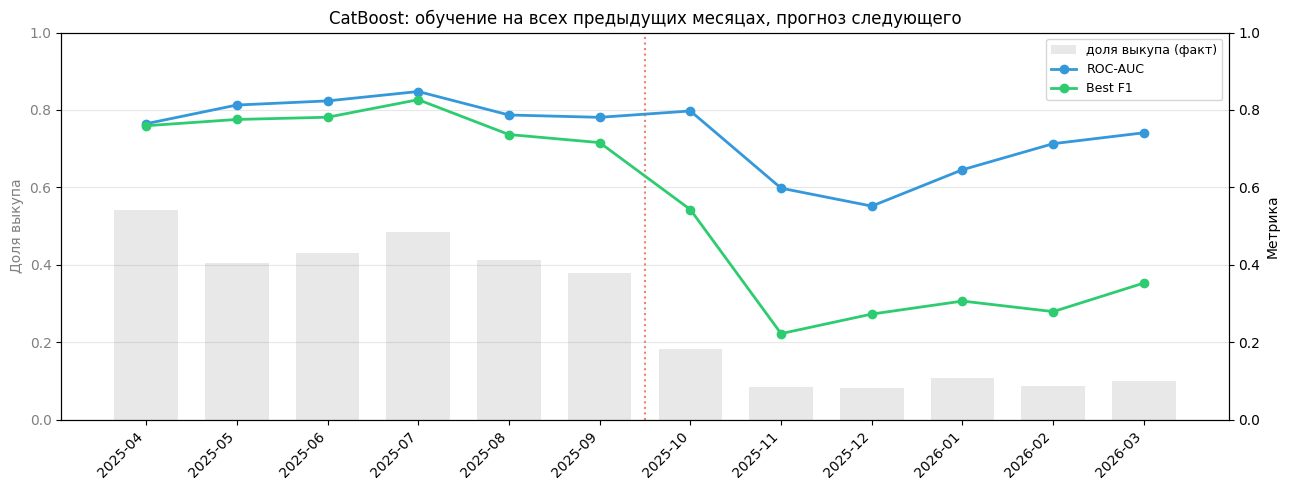

In [3]:
plot_cumulative_metrics(
    results_cb,
    title='CatBoost: обучение на всех предыдущих месяцах, прогноз следующего',
)
plt.show()


Хронологическая картина для CatBoost повторяет логистическую регрессию: наблюдается просадка в **октября** 2025 и затема монотонное улучшение метрик

### Метрики финальной Catboost модели

In [4]:
train_df, test_df = split_by_month(new, train_through='2026-02', test_month='2026-03')
print(f'train rows = {len(train_df)}   test rows = {len(test_df)}')

train_pool = Pool(train_df[all_features], train_df[TARGET].values, cat_features=cat_idx)
test_pool = Pool(test_df[all_features], test_df[TARGET].values, cat_features=cat_idx)

model_cb = CatBoostClassifier(**CB_PARAMS)
model_cb.fit(train_pool, verbose=0)

proba_cb = model_cb.predict_proba(test_pool)[:, 1]
y_test = test_df[TARGET].astype(int).values
f1_cb, thr_cb = best_f1_threshold(y_test, proba_cb)
metrics_cb = compute_classification_metrics(y_test, proba_cb, threshold=thr_cb)
print_metrics(metrics_cb, title='CatBoost — март 2026 (финальная модель)')


train rows = 4006   test rows = 191
CatBoost — март 2026 (финальная модель)
| Метрика            | Значение                   |
|--------------------|----------------------------|
| Порог решения      | 0.23                       |
| Объём выборки      | 191                        |
| Доля выкупа (факт) | 9.9%                       |
| Accuracy           | 82.7%                      |
| Balanced accuracy  | 67.0%                      |
| Precision          | 28.1%                      |
| Recall             | 47.4%                      |
| F1                 | 35.3%                      |
| Matthews corrcoef  | 0.2725                     |
| ROC-AUC            | 0.7411                     |
| PR-AUC             | 0.2913                     |
| Confusion matrix   | TN=149  FP=23  FN=10  TP=9 |


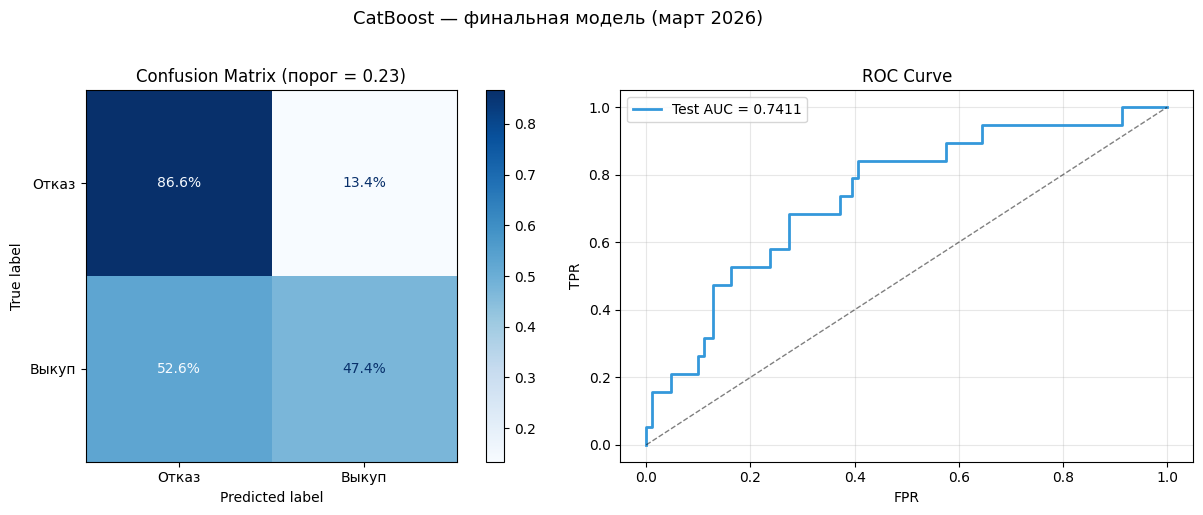

In [5]:
plot_final_metrics_panels(
    y_test, proba_cb,
    threshold=thr_cb,
    title='CatBoost — финальная модель (март 2026)',
)
plt.show()


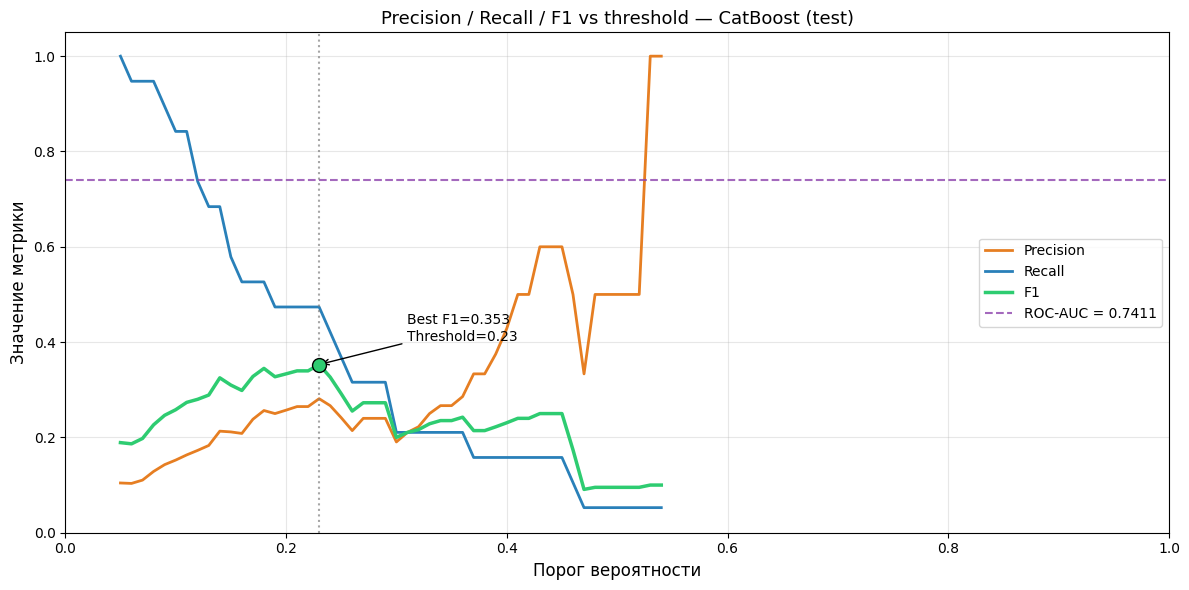

In [6]:
fig, _, _ = plot_threshold_sweep(
    y_test, proba_cb,
    title='Precision / Recall / F1 vs threshold — CatBoost (test)',
)
plt.show()


По confusion matrix видно, что Catboost склонна к переобучению и на самом деле в большинстве случаев просто предсказывает отказ. Такая карина ожидаема ввиду того, что тестовая выборка крайне не сбалансированная (всего 19 выкупов на 171 отказа)

### SHAP анализ значимости признаков

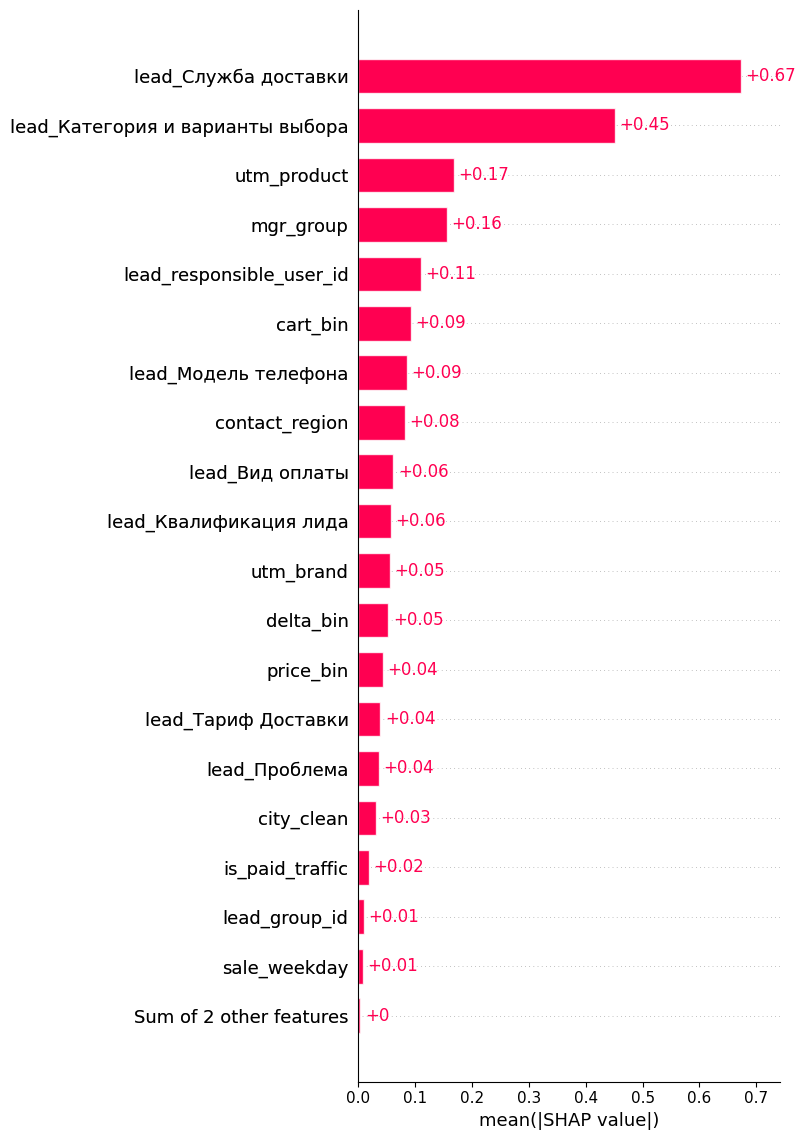

In [7]:
explainer = shap.TreeExplainer(model_cb)
explanation = explainer(test_pool)
explanation.feature_names = list(all_features)

shap.plots.bar(explanation, max_display=20, show=False)
plt.tight_layout()
plt.show()


Значимость признаков плюс минус такая же, как и в логистической регрессии. Но стоит отметить, что для Catboost самым значимым признаком стал `lead_Служба доставки`, а `lead_Вид оплаты` сместился на более низкие позиции. А в логистической регрессии наблюдается обратная ситуация

---

## Сравнение с линейной моделью

In [8]:
pipe_lr = joblib.load(DATA_DIR / 'logreg_new.joblib')
proba_lr = pipe_lr.predict_proba(test_df[feat_cols.all_feature_cols])[:, 1]
f1_lr, thr_lr = best_f1_threshold(y_test, proba_lr)
metrics_lr = compute_classification_metrics(y_test, proba_lr, threshold=thr_lr)

print(format_comparison_table(
    {'LogReg': metrics_lr, 'CatBoost': metrics_cb},
    title='Март 2026 — сравнение финальных моделей',
))


Март 2026 — сравнение финальных моделей
| Метрика            | LogReg   | CatBoost   |
|--------------------|----------|------------|
| Порог решения      | 0.15     | 0.23       |
| Объём выборки      | 191      | 191        |
| Доля выкупа (факт) | 9.9%     | 9.9%       |
| Accuracy           | 77.5%    | 82.7%      |
| Balanced accuracy  | 73.5%    | 67.0%      |
| Precision          | 26.0%    | 28.1%      |
| Recall             | 68.4%    | 47.4%      |
| F1                 | 37.7%    | 35.3%      |
| Matthews corrcoef  | 0.3194   | 0.2725     |
| ROC-AUC            | 0.7524   | 0.7411     |
| PR-AUC             | 0.2407   | 0.2913     |


Проводя сравнительный анализ логистической регрессии и Catboost видно, что линейная модель справляется на удивление лучше, чем нелинейная модель – Catboost. Данный факт является удивительным, но вполне объясним сильным дисбалансом целевой переменной и сложным меняющимся поведением клиентов

---

## Сохранение модели

In [9]:
model_cb.save_model(str(DATA_DIR / 'catboost_new.cbm'))
print(f'сохранено: {DATA_DIR / "catboost_new.cbm"}')


сохранено: data/catboost_new.cbm
